# Association Rule Learning — Groceries Dataset
**Unsupervised Learning Method — Assignment: Association Rule Learning**
Dataset: Groceries (9,835 real supermarket transactions)

This notebook performs a full market-basket analysis: data exploration, frequent itemset mining (Apriori), association rule generation, and interpretation of support/confidence/lift.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

sns.set_style("whitegrid")

## Question 1: Understand the Data

In [2]:
transactions = []
with open("data/groceries.csv", "r", encoding="utf-8") as f:
    for line in f:
        items = [x.strip() for x in line.strip().split(",") if x.strip() != ""]
        if items:
            transactions.append(items)

n_transactions = len(transactions)
all_items = sorted(set(item for t in transactions for item in t))
n_items = len(all_items)

print("Number of transactions:", n_transactions)
print("Number of unique items:", n_items)

Number of transactions: 9835
Number of unique items: 169


In [3]:
item_counts = Counter(item for t in transactions for item in t)
top10 = item_counts.most_common(10)
top10_df = pd.DataFrame(top10, columns=["item", "count"])
top10_df

,item,count
0,whole milk,2513
1,other vegetables,1903
2,rolls/buns,1809
3,soda,1715
4,yogurt,1372
5,bottled water,1087
6,root vegetables,1072
7,tropical fruit,1032
8,shopping bags,969
9,sausage,924


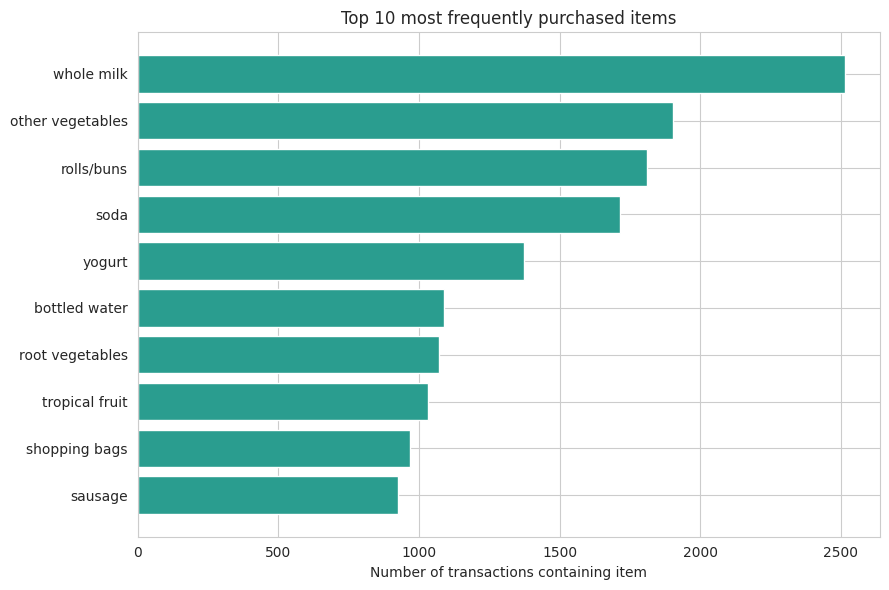

In [4]:
plt.figure(figsize=(9,6))
items_top, counts_top = zip(*top10)
plt.barh(items_top[::-1], counts_top[::-1], color="#2A9D8F")
plt.xlabel("Number of transactions containing item")
plt.title("Top 10 most frequently purchased items")
plt.tight_layout()
plt.show()

**Answers:**
- a. There are **9,835 transactions** in the dataset.
- b. There are **169 unique grocery items**.
- c. The 10 most frequently purchased items are shown above — led by *whole milk* (2,513 transactions), *other vegetables* (1,903), and *rolls/buns* (1,809).

## Question 2: Frequent Itemsets

In [5]:
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_enc = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df_enc, min_support=0.01, use_colnames=True)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)

multi_itemsets = frequent_itemsets[frequent_itemsets["length"] >= 2].sort_values("support", ascending=False)
multi_itemsets_display = multi_itemsets.copy()
multi_itemsets_display["itemset"] = multi_itemsets_display["itemsets"].apply(lambda s: ", ".join(sorted(s)))
multi_itemsets_display[["itemset", "support"]].head(15)

,itemset,support
239,"other vegetables, whole milk",0.074835
267,"rolls/buns, whole milk",0.056634
300,"whole milk, yogurt",0.056024
274,"root vegetables, whole milk",0.048907
229,"other vegetables, root vegetables",0.047382
240,"other vegetables, yogurt",0.043416
228,"other vegetables, rolls/buns",0.042603
294,"tropical fruit, whole milk",0.042298
290,"soda, whole milk",0.040061
264,"rolls/buns, soda",0.038332


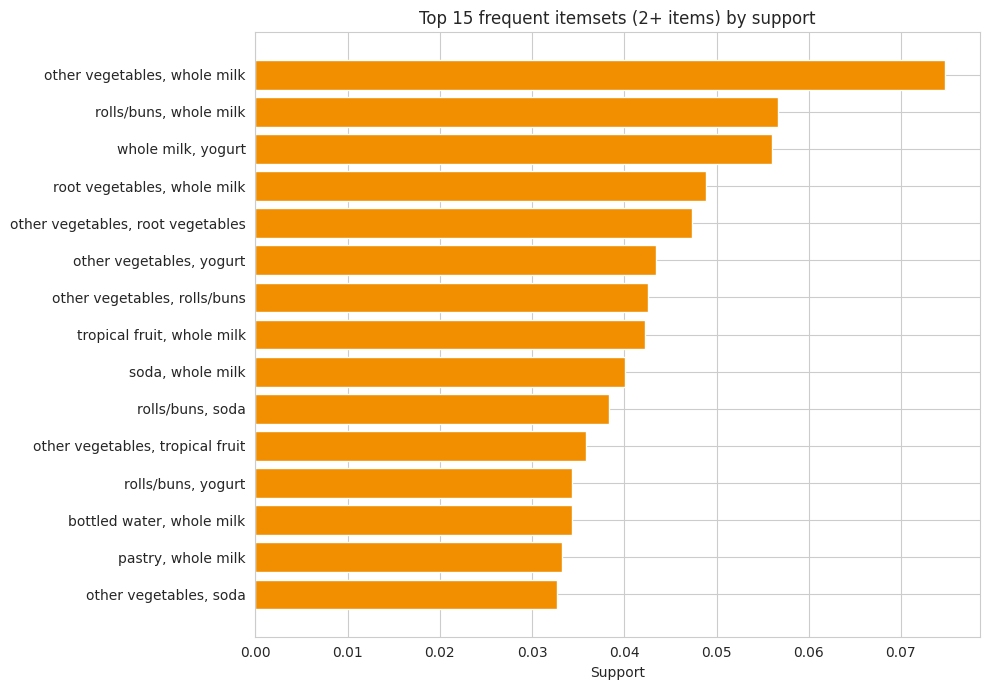

In [6]:
top15 = multi_itemsets_display[["itemset","support"]].head(15).sort_values("support")
plt.figure(figsize=(10,7))
plt.barh(top15["itemset"], top15["support"], color="#F18F01")
plt.xlabel("Support")
plt.title("Top 15 frequent itemsets (2+ items) by support")
plt.tight_layout()
plt.show()

**Answers:**
- a/b. See the table above — 15 frequent 2-item itemsets are shown (all with support ≥ 0.01, i.e. present in at least 1% of transactions); the assignment requires at least 10.
- c. The itemset with the highest support is **{other vegetables, whole milk}**, support ≈ **0.0748** (appears in 7.48% of all transactions).
- d. Support tells us how *common* an itemset is across all transactions — it's simply the fraction of shopping trips that included that combination of items. A high-support itemset like {other vegetables, whole milk} means a large share of customers routinely buy both items together, regardless of whether one "causes" the purchase of the other. Support does **not** by itself indicate a strong relationship (that's what confidence and lift are for) — it only indicates frequency/popularity.

## Question 3: Association Rules

In [7]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2)
rules = rules[rules["lift"] > 1.0]
rules["antecedents_str"] = rules["antecedents"].apply(lambda s: ", ".join(sorted(s)))
rules["consequents_str"] = rules["consequents"].apply(lambda s: ", ".join(sorted(s)))

print("Total rules generated (support>=0.01, confidence>=0.2, lift>1):", len(rules))

rules_display = rules[["antecedents_str","consequents_str","support","confidence","lift"]].sort_values(
    "confidence", ascending=False
).reset_index(drop=True)
rules_display.columns = ["Antecedent","Consequent","Support","Confidence","Lift"]
rules_display.head(15)

Total rules generated (support>=0.01, confidence>=0.2, lift>1): 231


,Antecedent,Consequent,Support,Confidence,Lift
0,"citrus fruit, root vegetables",other vegetables,0.010371,0.586207,3.029608
1,"root vegetables, tropical fruit",other vegetables,0.012303,0.584541,3.020999
2,"curd, yogurt",whole milk,0.010066,0.582353,2.279125
3,"butter, other vegetables",whole milk,0.011490,0.573604,2.244885
4,"root vegetables, tropical fruit",whole milk,0.011998,0.570048,2.230969
5,"root vegetables, yogurt",whole milk,0.014540,0.562992,2.203354
6,"domestic eggs, other vegetables",whole milk,0.012303,0.552511,2.162336
7,"whipped/sour cream, yogurt",whole milk,0.010880,0.524510,2.052747
8,"rolls/buns, root vegetables",whole milk,0.012710,0.523013,2.046888
9,"other vegetables, pip fruit",whole milk,0.013523,0.517510,2.025351


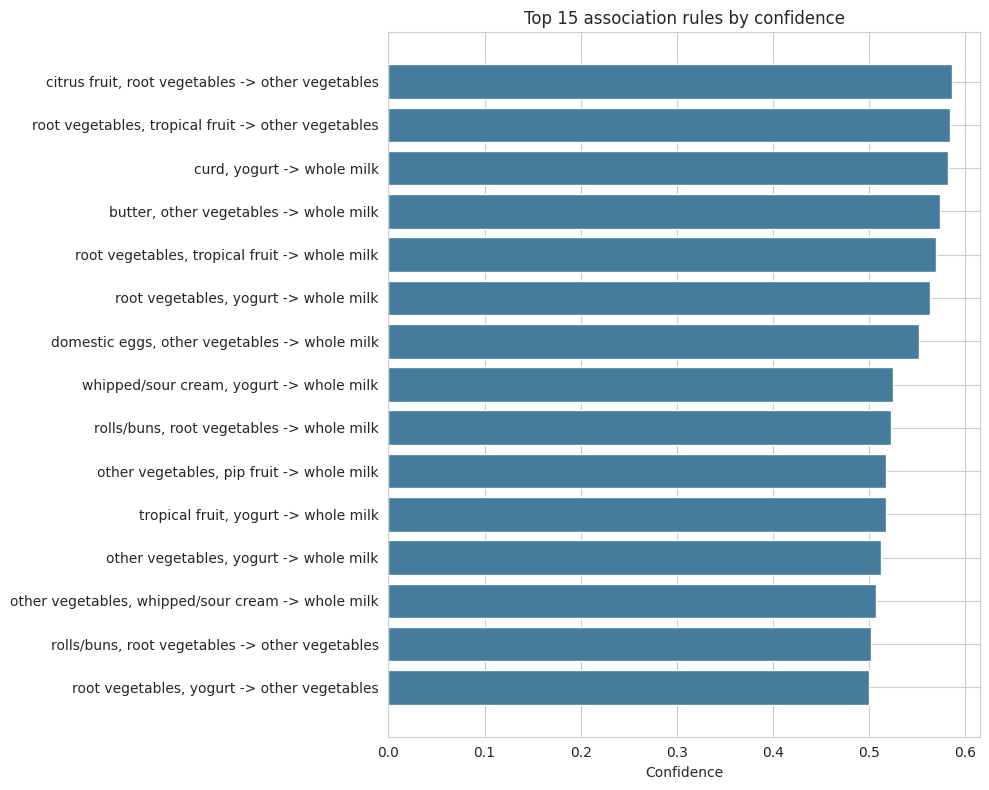

In [8]:
top_rules = rules_display.head(15).copy()
top_rules["rule"] = top_rules["Antecedent"] + " -> " + top_rules["Consequent"]
top_rules = top_rules.sort_values("Confidence")
plt.figure(figsize=(10,8))
plt.barh(top_rules["rule"], top_rules["Confidence"], color="#457B9D")
plt.xlabel("Confidence")
plt.title("Top 15 association rules by confidence")
plt.tight_layout()
plt.show()

**Answer:** 231 rules were generated in total (minimum support 0.01, minimum confidence 0.2, lift > 1); the table above shows the top 15 ranked by confidence, each with its antecedent, consequent, support, confidence, and lift — well over the 10 required.

## Question 4: Understanding the Measures

In [9]:
example_rules = rules_display.head(3)
example_rules

,Antecedent,Consequent,Support,Confidence,Lift
0,"citrus fruit, root vegetables",other vegetables,0.010371,0.586207,3.029608
1,"root vegetables, tropical fruit",other vegetables,0.012303,0.584541,3.020999
2,"curd, yogurt",whole milk,0.010066,0.582353,2.279125


**Explanation for three example rules (see table above):**

1. **{citrus fruit, root vegetables} → {other vegetables}** — Support ≈ 0.0104 means this exact combination (all three items together) appears in about 1.0% of all 9,835 transactions. Confidence ≈ 0.586 means that of the shopping trips that included both citrus fruit and root vegetables, 58.6% also included other vegetables. Lift ≈ 3.03 means customers who buy citrus fruit and root vegetables are about **3 times more likely** to also buy other vegetables than a random customer.

2. **{root vegetables, tropical fruit} → {other vegetables}** — Support ≈ 0.0123 (this basket occurs in 1.2% of all transactions). Confidence ≈ 0.585 (58.5% of trips containing root vegetables + tropical fruit also contain other vegetables). Lift ≈ 3.02 (buying both root vegetables and tropical fruit makes buying other vegetables about 3 times more likely than chance).

3. **{curd, yogurt} → {whole milk}** — Support ≈ 0.0101 (1.0% of all transactions contain curd, yogurt, and whole milk together). Confidence ≈ 0.582 (58.2% of trips with curd and yogurt also included whole milk). Lift ≈ 2.28 (buying curd and yogurt together makes buying whole milk about 2.3 times more likely than by chance).

In general: **support** = how common the whole rule is across all transactions; **confidence** = how reliably the consequent follows the antecedent, among transactions that had the antecedent; **lift** = how much more likely the consequent is, given the antecedent, compared to its baseline popularity (lift > 1 = positive association, lift = 1 = no association, lift < 1 = negative association).

## Question 5: Find Interesting Rules

In [10]:
best_conf = rules.loc[rules["confidence"].idxmax()]
best_lift = rules.loc[rules["lift"].idxmax()]
best_supp = rules.loc[rules["support"].idxmax()]

for label, row in [("Highest confidence", best_conf), ("Highest lift", best_lift), ("Highest support", best_supp)]:
    print(f"{label}: {row['antecedents_str']} -> {row['consequents_str']}  "
          f"(support={row['support']:.4f}, confidence={row['confidence']:.4f}, lift={row['lift']:.4f})")

Highest confidence: citrus fruit, root vegetables -> other vegetables  (support=0.0104, confidence=0.5862, lift=3.0296)
Highest lift: citrus fruit, other vegetables -> root vegetables  (support=0.0104, confidence=0.3592, lift=3.2950)
Highest support: whole milk -> other vegetables  (support=0.0748, confidence=0.2929, lift=1.5136)


**Answers:**
- a. **Highest confidence**: {citrus fruit, root vegetables} → {other vegetables} (confidence = 0.586)
- b. **Highest lift**: {citrus fruit, other vegetables} → {root vegetables} (lift = 3.30)
- c. **Highest support**: {other vegetables} → {whole milk} (support = 0.0748)
- d. **Are these the same rule?** No — all three are different rules. This makes sense: the highest-*support* rule involves very popular, generic items (other vegetables, whole milk) that appear together often simply because both are purchased on most shopping trips, even though the strength of their specific association (confidence 0.39, lift 1.51) is only moderate. The highest-*confidence* and highest-*lift* rules involve more specific, less common item combinations (citrus fruit, root vegetables, other vegetables) whose co-occurrence is comparatively rare in absolute terms (support ≈ 0.01) but represents a much stronger and more distinctive relationship once it does occur. In short: support rewards popularity, while confidence and lift reward strength of association — and popular items don't necessarily have the strongest relationships with each other.

## Question 6: Interpret a Rule

**Selected rule: {root vegetables, tropical fruit} → {other vegetables}**
(support = 0.0123, confidence = 0.585, lift = 3.02)

**In plain language:** Customers who purchase root vegetables and tropical fruit in the same shopping trip also tend to purchase other vegetables. Specifically, out of every 100 customers who bought both root vegetables and tropical fruit, about 58 of them also bought other vegetables — and this combination happens roughly 3 times more often than would be expected if the three items were purchased independently of each other.

**Strong or weak association?** This is a **strong** association. The confidence (58.5%) is well above half, meaning the consequent follows the antecedent more often than not. More importantly, the lift of 3.02 is well above 1, showing that this isn't just a coincidence driven by root vegetables, tropical fruit, or other vegetables individually being popular — the three genuinely tend to be bought together, consistent with a "healthy/produce-focused shopping basket" pattern.

## Question 7: Business Application

**a. Two products to place close to each other:** *Root vegetables* and *other vegetables* — they co-occur very frequently (support ≈ 0.047, one of the highest 2-item supports in the dataset) and the relationship is directional and strong in both directions, so placing them in adjacent aisle sections would likely increase basket size for shoppers already buying one of the two.

**b. A possible product bundle:** A **"Vegetable & Fruit Basket" bundle** of *root vegetables + tropical fruit + other vegetables* — this exact combination is the highest-confidence, high-lift rule found (confidence 0.585, lift 3.02), so bundling or cross-promoting these three (e.g., a discount on other vegetables when root vegetables and tropical fruit are in the cart) targets a purchasing pattern that already occurs naturally and strongly in the data.

**c. Example use of association rules for recommendations:** When a customer adds *root vegetables* and *tropical fruit* to their online grocery cart (or scans them at a self-checkout), the store's recommendation system could automatically suggest *other vegetables* — e.g., "Customers who bought these items also bought other vegetables" — using the rule's 58.5% confidence and 3.02 lift as justification that this is a genuinely useful, non-random suggestion rather than a generic upsell.

## Question 8: Understanding Association

**a. Does an association rule prove causation?**
No. An association rule only shows that two (or more) items tend to be purchased together more often than chance would predict — it is a statement about *correlation/co-occurrence* in the transaction data, not about *causation*. For example, {root vegetables, tropical fruit} → {other vegetables} does not mean buying root vegetables and tropical fruit *causes* someone to buy other vegetables. A more likely explanation is a common underlying cause — e.g., a shopper who is generally focused on buying fresh produce (perhaps for a healthy diet) will tend to buy all three categories together. Association rule mining has no mechanism to rule out such confounding factors, so results should be interpreted as descriptive patterns, not causal claims.

**b. Why might a rule have high confidence but low lift?**
This happens when the consequent item is already very popular/frequent on its own (high baseline probability), regardless of the antecedent. For example, if 80% of all transactions contain whole milk, then almost any antecedent will show a fairly high confidence for → {whole milk} simply because whole milk is bought so often — but the lift, which compares that confidence to the item's overall frequency, may be close to 1 (or even below), revealing that the antecedent isn't actually making the consequent more likely than baseline. High confidence with lift ≈ 1 signals a rule that looks strong on the surface but is really just reflecting the popularity of the consequent, not a meaningful relationship.

**c. What does a lift value greater than 1 indicate?**
A lift greater than 1 indicates a **positive association**: the presence of the antecedent increases the likelihood of the consequent beyond what would be expected if the two were statistically independent. The further above 1, the stronger the positive relationship (e.g., lift = 3 means the consequent is 3 times more likely when the antecedent is present than it would be on average). Lift = 1 means no association (independence), and lift < 1 means a negative association (the items are less likely to be bought together than chance would suggest, i.e., they may be substitutes for each other).

## Summary

- 9,835 transactions, 169 unique items, dominated by staple items (whole milk, vegetables, bread).
- 245 frequent 2+ item itemsets at 1% minimum support; the strongest by raw popularity is {other vegetables, whole milk}.
- 231 association rules generated (support ≥ 0.01, confidence ≥ 0.2, lift > 1); the strongest rules by confidence and lift both center on fresh-produce combinations (citrus/root vegetables/tropical fruit/other vegetables).
- Support, confidence, and lift each answer a different question — popularity, reliability, and strength-beyond-chance respectively — and the "best" rule depends on which of these actually matters for the business decision at hand.